# 03 Data analysis

## Setup

### Load Libraries

In [21]:
library(tidyverse)
library(plotrix)
library(RColorBrewer)
library(patchwork)
library(tools)
library(readxl)
library(scales)

options(warn = -1)

### Set working directory 

In [ ]:
wd <- "/path/to/03_image_analysis/06_growth_at_28"
setwd(wd)

### Load and tidy metadata table

In [ ]:
# Load Excel metadata table
md_path <- file.path(wd, "02_data", "tables", "growth_28C_asssay_layout.xlsx")
    
md <- read_excel(md_path)

# Convert to tidy layout
tidy_md <- md %>%
  gather(key = "column", value = "value", -row, -type) %>%
  pivot_wider(names_from = type, values_from = value) %>%
  mutate(column = as.numeric(column)) %>%
  rename(col = column) %>%
  arrange(row, col)


 ### Load and clean per-cell data

In [ ]:
# Load per-cell measurement table
data_path <- file.path(wd, "02_data", "tables", "cell_analysis.csv")
data_raw <- read.csv(data_path, header = TRUE, check.names = TRUE, sep = ",")

# Extract information from filename
data <- data_raw %>%
  mutate(filename = basename(filename)) %>%
  separate(filename, into = c("temperature", "row", "col", "region"), sep = "_", remove = FALSE) %>%
  select(filename, temperature, row, col, region, cell_label, area) %>%
  arrange(filename)


## Analysis and Visualization

### Summarize data by region

In [8]:
# Summarize per-region cell counts and mean/max area
data_summary_regions <- data %>%
  group_by(temperature, row, col, region) %>%
  summarise(
    n.region = n(),
    across(area, list(
      region.mean = ~mean(.x, na.rm = TRUE),
      region.max  = ~max(.x, na.rm = TRUE)
    )),
    .groups = "drop"
  )


### Summarize data by well

In [9]:
# Summarize per-well values across regions
data_summary_wells <- data_summary_regions %>%
  group_by(row, col) %>%
  summarise(
    n = n(),  # Total number of regions
    across(
      .cols = where(is.numeric),
      .fns = list(
        mean = ~mean(.x, na.rm = TRUE),
        se   = ~sd(.x, na.rm = TRUE) / sqrt(n()), 
        max  = ~max(.x, na.rm = TRUE)
      ),
      .names = "{.col}.{.fn}"
    ),
    .groups = "drop"
  ) %>%
  mutate(col = as.numeric(col))


### Merge well summary with metadata

In [10]:
# Merge well summary with metadata and sort by layout
data_summary_wells_md <- data_summary_wells %>%
  full_join(tidy_md, by = c("row", "col")) %>%
  arrange(row, col)

# Replace missing cell counts (empty wells) with 0
data_summary_wells_md <- data_summary_wells_md %>%
  replace_na(list(n = 0))


### Join region data with metadata and summarize

In [13]:
# Join region-level data with metadata
data_summary <- data_summary_regions %>%
  mutate(col = as.numeric(col)) %>%
  left_join(tidy_md, by = c("row", "col")) %>%
  select(temperature, row, col, region, n.region, strain, concentration) %>%
  group_by(temperature, strain, concentration) %>%
  summarise(
    n = n(),
    across(
      n.region,
      .fns = list(
        mean = ~mean(.x, na.rm = TRUE),
        sd   = ~sd(.x, na.rm = TRUE),
        max  = ~max(.x, na.rm = TRUE)
      ),
      .names = "{.col}.{.fn}"
    ),
    .groups = "drop"
  )


### Define colors and field of view scaling

In [11]:
# Define color palettes
wt_colors      <- brewer.pal(n = 9, name = "Greens")
disfp_colors   <- brewer.pal(n = 9, name = "Purples")
rescue_colors  <- brewer.pal(n = 9, name = "Blues")

color_nr <- 6
strain_colors <- c("wt" = wt_colors[color_nr], "ko" = disfp_colors[color_nr])

# Define strain labels for plotting
strain_rename <- c(
  "ko" = bquote(atop(italic(disfp)^"–", "mutant")),
  "wt" = bquote(atop("Ax2", "wildtype"))
)

# Define strain factor levels
strain_levels <- c("wt", "ko")

# Define field of view dimensions and calculate scale factor
pixels_x <- 2048
pixels_y <- 2048
physical_length_in_uM_x <- 656.23
physical_length_in_uM_y <- 656.23

scale_factor_x <- physical_length_in_uM_x / pixels_x
scale_factor_y <- physical_length_in_uM_y / pixels_y
scale_factor   <- (scale_factor_x + scale_factor_y) / 2

# Calculate field of view area in mm²
FOV_area_mm2 <- (physical_length_in_uM_x * physical_length_in_uM_y) / 1e6


### Adjust factors and plot growth

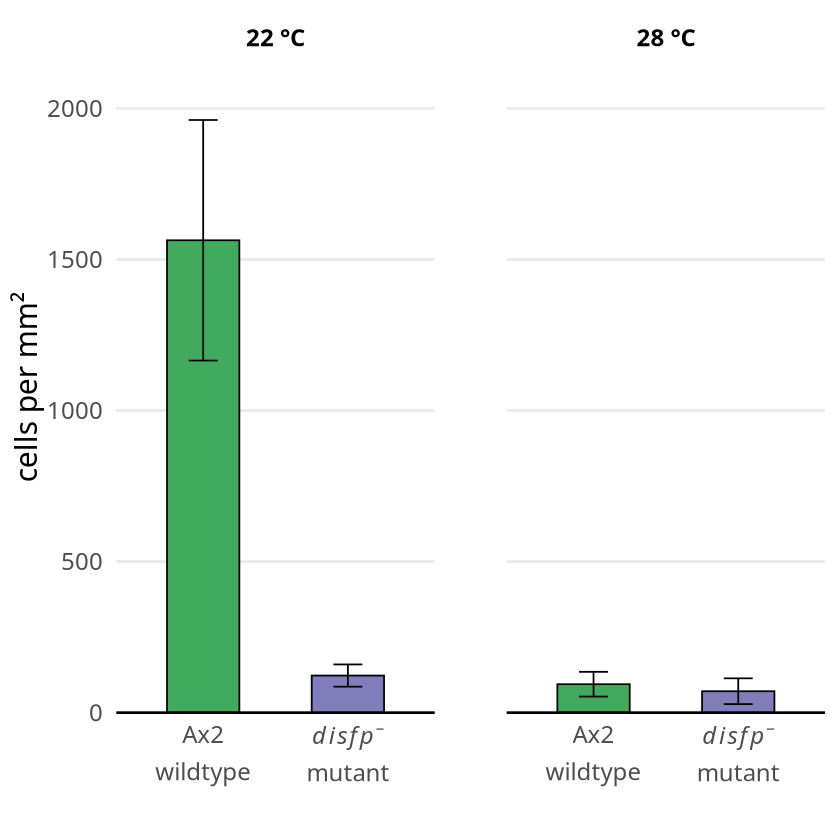

In [24]:
# Set strain as ordered factor
data_summary <- data_summary %>%
  mutate(strain = factor(strain, levels = strain_levels))

# Plot cell density at 30,000 concentration, split by temperature
data_summary %>%
  filter(concentration == 30000) %>%
  mutate(temperature = str_replace_all(temperature, c("22C" = "22 °C", "28C" = "28 °C"))) %>%
  ggplot(aes(x = strain, y = n.region.mean / FOV_area_mm2, fill = strain)) +
  geom_col(position = position_dodge(width = 0.6), width = 0.5, color = "black") +
  geom_errorbar(
    aes(ymin = (n.region.mean - n.region.sd) / FOV_area_mm2,
        ymax = (n.region.mean + n.region.sd) / FOV_area_mm2),
    position = position_dodge(width = 0.6), width = 0.2
  ) +
  facet_wrap(~temperature) +
  labs(y = "cells per mm²", x = "") +
  scale_fill_manual(values = strain_colors, labels = strain_rename) +
  scale_x_discrete(labels = strain_rename) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.1))) +
  guides(fill = guide_legend(direction = "vertical")) +
  theme_minimal(base_size = 18) +
  theme(
    panel.border = element_blank(),
    panel.spacing = unit(3, "lines"),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    axis.line.x = element_line(color = "black", size = 0.75),
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    strip.text.x = element_text(color = "black", face = "bold"),
    strip.background = element_rect(colour = "white", fill = "white"),
    legend.position = "none"
  )
